In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix , accuracy_score , precision_score , recall_score , classification_report , f1_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier


In [ ]:
# Loading the dataset

df = pd.read_csv('/content/Telco-Customer-Churn.csv')

Exploratory Data Analyasis

In [ ]:
# Checking data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Checking for every possible missing data
df.isna().sum()

df.isnull().sum()

(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Filling the missing data

df = df.replace(" ", np.nan)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
df[["TotalCharges"]] = imputer.fit_transform(df[["TotalCharges"]])

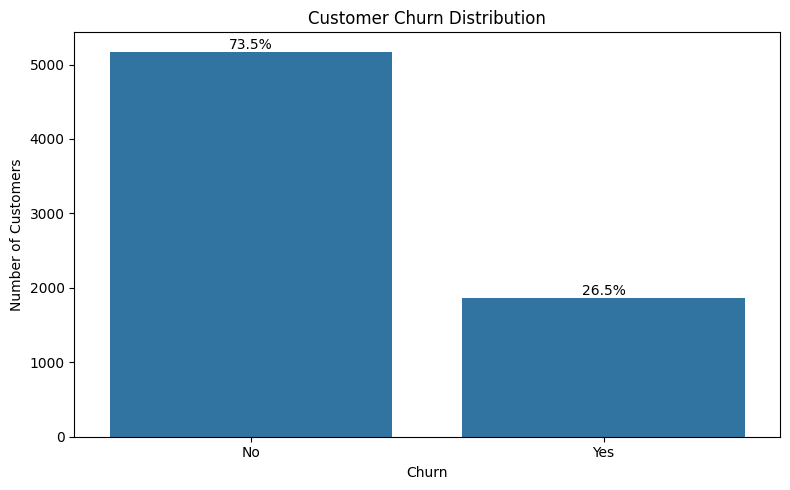

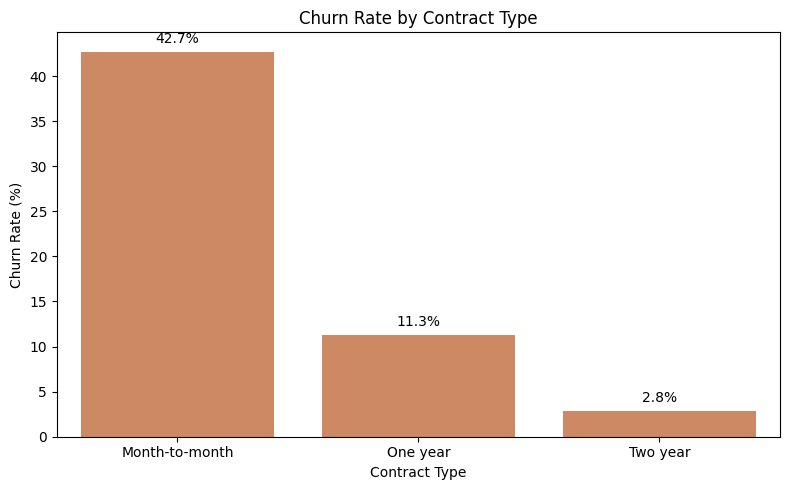

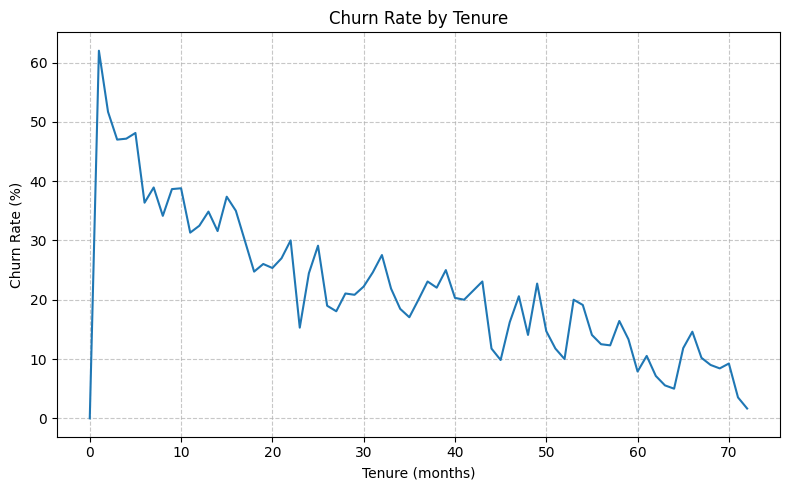

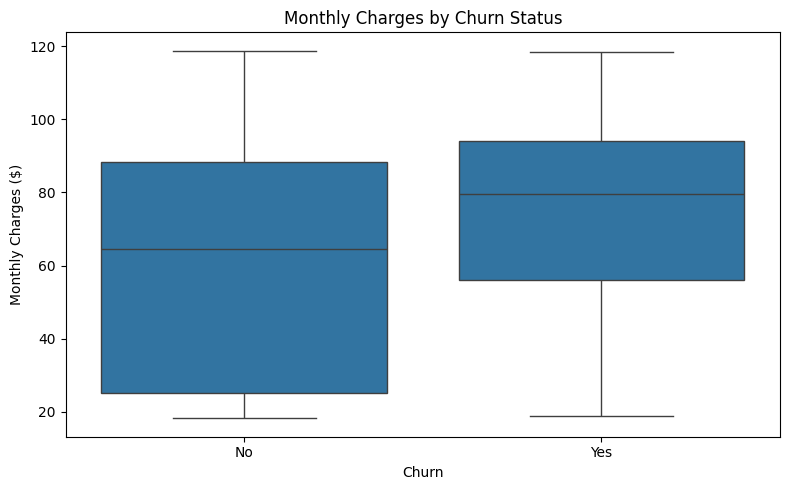

In [ ]:
# visualization

# Churn distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Churn')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
for p in ax.patches:
    pct = f"{100 * p.get_height() / len(df):.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Churn rate by contract type

contract_churn = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn.values, color="#DD8452")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
for i, v in enumerate(contract_churn.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

# Churn rate by Tebure

tenure_churn = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean()).reset_index()
tenure_churn['Churn Rate (%)'] = tenure_churn['Churn'] * 100

plt.figure(figsize=(8, 5))
sns.lineplot(x='tenure', y='Churn Rate (%)', data=tenure_churn)
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Monthly charges vs. churn

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

In [ ]:
# replacing (Yes , No) with (1 , 0) so the model can understand

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn' ,  'OnlineSecurity' ,'DeviceProtection' , 'TechSupport' , 'StreamingTV' ,  'StreamingMovies' ,  'OnlineBackup' ]
for col in binary_cols:
    df[col] = df[col].replace({'No' :0 , 'No internet service':0, 'Yes':1})


contract_mapping = {
    'One year': 12,
    'Two year': 24,
    'Month-to-month': 1
}
df['Contract'] = df['Contract'].map(contract_mapping)

/tmp/ipykernel_1141/3083835517.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'No' :0 , 'No internet service':0, 'Yes':1})


One Hot Encoding

In [ ]:
# Apply one-hot encoding to categorical features
ohe = OneHotEncoder(handle_unknown='ignore' , sparse_output= False).set_output(transform='pandas')

ohe_tf = ohe.fit_transform(df[['MultipleLines']])

ohe = OneHotEncoder(handle_unknown='ignore' , sparse_output= False).set_output(transform='pandas')

ohe_tf2 = ohe.fit_transform(df[['InternetService']])

ohe = OneHotEncoder(handle_unknown='ignore' , sparse_output= False).set_output(transform='pandas')

ohe_tf3 = ohe.fit_transform(df[['PaymentMethod']])

In [ ]:
# Add encoded features and remove original columns
df = pd.concat([df , ohe_tf ,ohe_tf2 , ohe_tf3 ] , axis=1).drop(['MultipleLines' , 'gender' , 'customerID' , 'PaymentMethod', 'InternetService'] , axis=1)

df.head(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,1,0,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0,0,34,1,1,0,1,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,0,2,1,1,1,0,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,0,45,0,1,0,1,1,0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,2,1,0,0,0,0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
#After Changing object columns to numerical by binary_cols and ohe , it's time to change the data type to int for it to work in ML models

df["Partner"] = df["Partner"].astype(int)
df["Dependents"] = df["Dependents"].astype(int)
df["PhoneService"] = df["PhoneService"].astype(int)
df["Contract"] = df["Contract"].astype(int)
df["MultipleLines_No"] = df["MultipleLines_No"].astype(int)
df["MultipleLines_Yes"] = df["MultipleLines_Yes"].astype(int)
df["MultipleLines_No phone service"] = df["MultipleLines_No phone service"].astype(int)
df["InternetService_DSL"] = df["InternetService_DSL"].astype(int)
df["InternetService_Fiber optic"] = df["InternetService_Fiber optic"].astype(int)
df["InternetService_No"] = df["InternetService_No"].astype(int)
df["PaymentMethod_Bank transfer (automatic)"] = df["PaymentMethod_Bank transfer (automatic)"].astype(int)
df["PaymentMethod_Credit card (automatic)"] = df["PaymentMethod_Credit card (automatic)"].astype(int)
df["PaymentMethod_Electronic check"] = df["PaymentMethod_Electronic check"].astype(int)
df["PaymentMethod_Mailed check"] = df["PaymentMethod_Mailed check"].astype(int)


Training the model

In [ ]:
# Split data into X and y
X = df.drop('Churn' , axis=1)
y = df['Churn']

X.shape , y.shape

((7043, 25), (7043,))

In [ ]:
# Split data and scale features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_proba = log_model.predict_proba(X_test_scaled)[: , 1]
threshold = 0.29
new_log = (log_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, new_log))
print("Precision:", precision_score(y_test, new_log))
print("Recall:", recall_score(y_test, new_log))
print(classification_report(y_test, new_log))

Accuracy: 0.7707594038325053
Precision: 0.5452898550724637
Recall: 0.806970509383378
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1036
           1       0.55      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



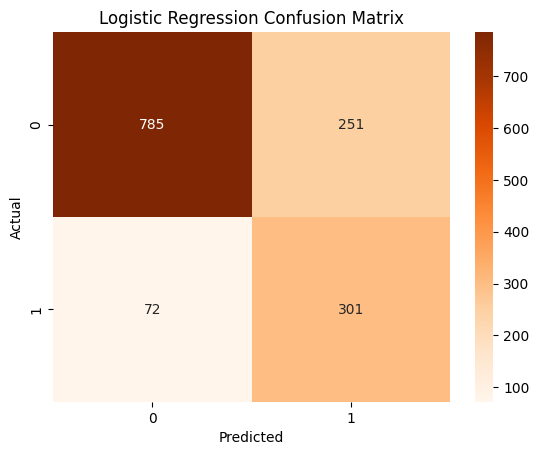

In [ ]:
cm_log = confusion_matrix(y_test, new_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Oranges")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Random Forest
rf = RandomForestClassifier(
    random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[: , 1]
threshold = 0.3
new_pred = (rf_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, new_pred))
print("Precision:", precision_score(y_test, new_pred))
print("Recall:", recall_score(y_test, new_pred))
print(classification_report(y_test, new_pred))

Accuracy: 0.7601135557132718
Precision: 0.5342465753424658
Recall: 0.7319034852546917
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1036
           1       0.53      0.73      0.62       373

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



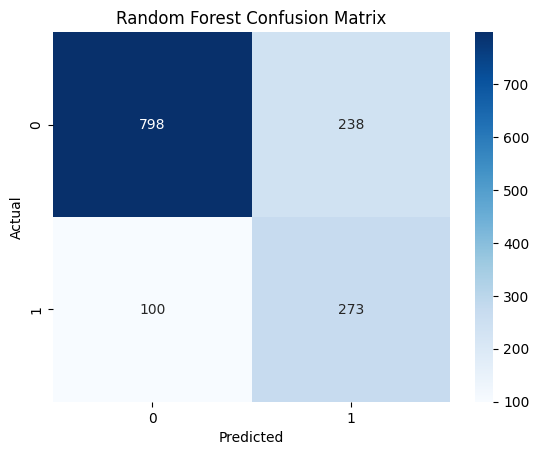

In [ ]:
cm_rf = confusion_matrix(y_test, new_pred)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# XGBoost
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[: , 1]
threshold = 0.3
new_xgb = (xgb_proba >= threshold).astype(int)

print("XGBoost Model Performance:")
print("Accuracy:", accuracy_score(y_test, new_xgb))
print("Precision:", precision_score(y_test, new_xgb))
print("Recall:", recall_score(y_test, new_xgb))
print(classification_report(y_test, new_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:25:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Performance:
Accuracy: 0.7601135557132718
Precision: 0.5363825363825364
Recall: 0.6916890080428955
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1036
           1       0.54      0.69      0.60       373

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



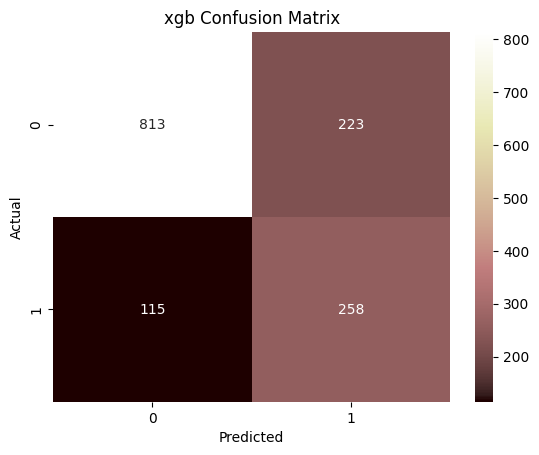

In [ ]:
cm_xgb = confusion_matrix(y_test, new_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="pink")
plt.title("xgb Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Comparing between each model

model_comparison = pd.DataFrame({
    'Model': [ 'Logistic Regression' , 'Random Forest', 'XGBoost'],
    'Accuracy': [
         accuracy_score(y_test, new_log),
        accuracy_score(y_test, new_pred),
        accuracy_score(y_test, new_xgb)

    ],
    'Precision': [
        precision_score(y_test, new_log),
        precision_score(y_test, new_pred),
        precision_score(y_test, new_xgb)

    ],
    'Recall': [
        recall_score(y_test, new_log),
        recall_score(y_test, new_pred),
        recall_score(y_test, new_xgb)

    ]
})
model_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.770759,0.545290,0.806971
1,Random Forest,0.760114,0.534247,0.731903
2,XGBoost,0.760114,0.536383,0.691689


                                    Feature  Importance
3                                    tenure    1.302502
14                             TotalCharges    0.602713
11                                 Contract    0.590313
13                           MonthlyCharges    0.563238
20                       InternetService_No    0.562797
19              InternetService_Fiber optic    0.529770
10                          StreamingMovies    0.221598
9                               StreamingTV    0.171271
12                         PaperlessBilling    0.163618
5                            OnlineSecurity    0.161862
8                               TechSupport    0.124651
23           PaymentMethod_Electronic check    0.119026
15                         MultipleLines_No    0.085975
17                        MultipleLines_Yes    0.077978
2                                Dependents    0.074171
18                      InternetService_DSL    0.066510
22    PaymentMethod_Credit card (automatic)    0

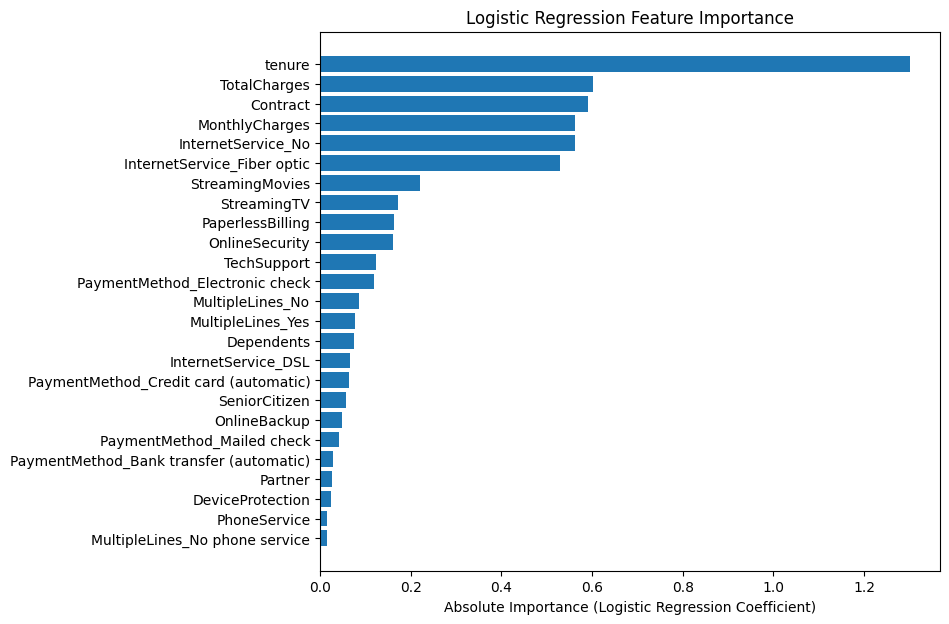

In [ ]:
# Feature Importances

importances = log_model.coef_[0]
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(importances)
}).sort_values('Importance', ascending=False)

print(feat_imp)

plt.figure(figsize=(8, 7))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Absolute Importance (Logistic Regression Coefficient)')
plt.title('Logistic Regression Feature Importance')
plt.show()

<Axes: ylabel='feature'>

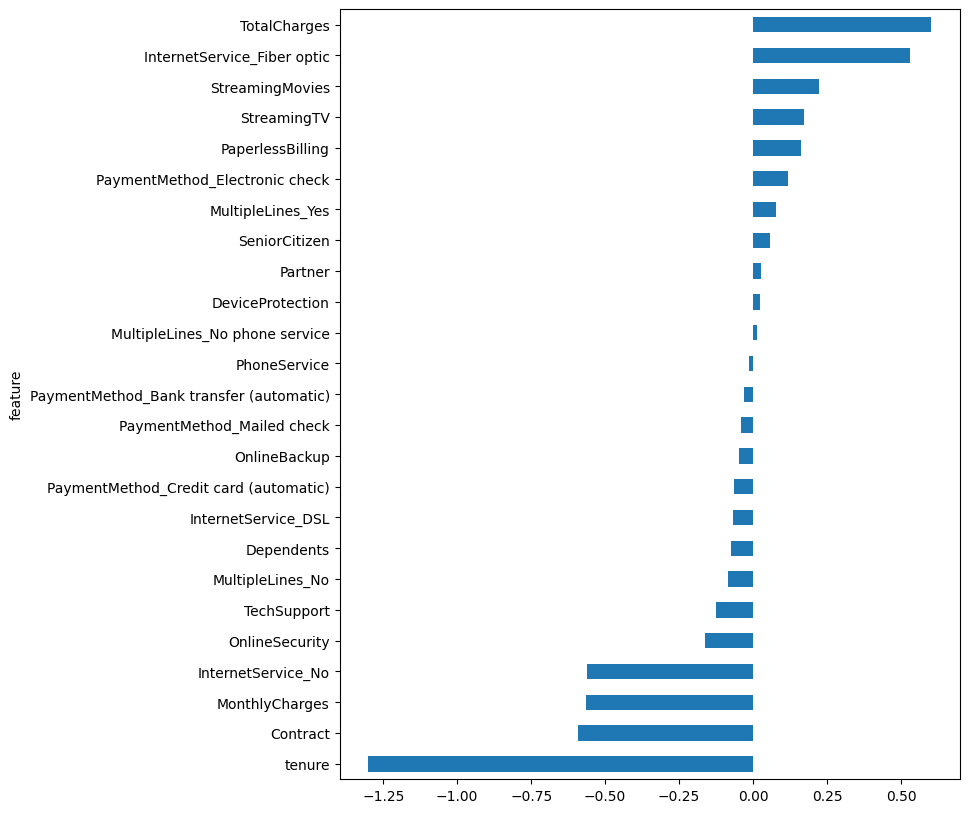

In [ ]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'Coefficient': log_model.coef_[0]}).sort_values('Coefficient')

coef_df.plot(x='feature', y='Coefficient', kind='barh', figsize=(8,10), legend=False)

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Assuming log_model and scaler are already fitted from previous cells
# To ensure robustness, we'll re-initialize and fit the OneHotEncoders

# Re-create a simplified original_df for fitting OHE and getting column names
# This assumes the original Telco-Customer-Churn.csv is still available and structure is known
original_df_for_ohe = pd.read_csv('/content/Telco-Customer-Churn.csv')

# Fit OneHotEncoder for 'MultipleLines' (still needed for default value)
ohe_multiple_lines = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_multiple_lines.fit(original_df_for_ohe[['MultipleLines']])

# Fit OneHotEncoder for 'InternetService'
ohe_internet_service = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_internet_service.fit(original_df_for_ohe[['InternetService']])

# Fit OneHotEncoder for 'PaymentMethod' (still needed for default value)
ohe_payment_method = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_payment_method.fit(original_df_for_ohe[['PaymentMethod']])

# Mean TotalCharges from training data for imputation
# This value is obtained from the kernel state `mean_total_charges`
global_mean_total_charges = 2291.154605263158

# Define the mapping for 'Contract' column
contract_mapping = {
    'One year': 12,
    'Two year': 24,
    'Month-to-month': 1
}

# Define the binary columns that were mapped 'No'/'Yes'/'No internet service' to 0/1
binary_cols_for_processing_map = {
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'OnlineSecurity': {'No': 0, 'Yes': 1, 'No internet service': 0},
    'OnlineBackup': {'No': 0, 'Yes': 1, 'No internet service': 0},
    'DeviceProtection': {'No': 0, 'Yes': 1, 'No internet service': 0},
    'TechSupport': {'No': 0, 'Yes': 1, 'No internet service': 0},
    'StreamingTV': {'No': 0, 'Yes': 1, 'No internet service': 0},
    'StreamingMovies': {'No': 0, 'Yes': 1, 'No internet service': 0}
}

def predict_churn(tenure, MonthlyCharges, TotalCharges, Contract,
                  InternetService_input, OnlineSecurity, TechSupport, StreamingTV, StreamingMovies):

    # Determine default values for features not in the explicit input list
    default_online_backup = 'No internet service' if InternetService_input == 'No' else 'No'
    default_device_protection = 'No internet service' if InternetService_input == 'No' else 'No'

    # Create a dictionary for all original input features, filling non-top-10 with sensible defaults
    input_features_dict = {
        'SeniorCitizen': 0, # Default
        'Partner': 'No',    # Default
        'Dependents': 'No', # Default
        'tenure': tenure,
        'PhoneService': 'Yes', # Default (most common)
        'MultipleLines': 'No', # Default
        'InternetService': InternetService_input,
        'OnlineSecurity': OnlineSecurity,
        'OnlineBackup': default_online_backup,
        'DeviceProtection': default_device_protection,
        'TechSupport': TechSupport,
        'StreamingTV': StreamingTV,
        'StreamingMovies': StreamingMovies,
        'Contract': Contract,
        'PaperlessBilling': 'Yes', # Default (was in previous top 10, now a default)
        'MonthlyCharges': MonthlyCharges,
        'TotalCharges': TotalCharges,
        'PaymentMethod': 'Mailed check' # Default
    }

    # Create a DataFrame from the inputs
    input_data = pd.DataFrame([input_features_dict])

    # Apply binary replacements using the defined map for relevant columns
    relevant_binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
                            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                            'StreamingTV', 'StreamingMovies']
    for col in relevant_binary_cols:
        if col in input_data.columns:
            input_data[col] = input_data[col].map(binary_cols_for_processing_map[col])

    # Apply contract mapping
    input_data['Contract'] = input_data['Contract'].map(contract_mapping)

    # Handle TotalCharges: convert to numeric and fill NaN
    input_data['TotalCharges'] = pd.to_numeric(input_data['TotalCharges'], errors='coerce')
    input_data['TotalCharges'] = input_data['TotalCharges'].fillna(global_mean_total_charges)

    # Apply One-Hot Encoding
    ohe_tf_ml = ohe_multiple_lines.transform(input_data[['MultipleLines']])
    ohe_tf_is = ohe_internet_service.transform(input_data[['InternetService']])
    ohe_tf_pm = ohe_payment_method.transform(input_data[['PaymentMethod']])

    # Concatenate the one-hot encoded columns and drop original categorical columns
    cols_to_drop_after_ohe = ['MultipleLines', 'InternetService', 'PaymentMethod']
    input_processed_temp = input_data.drop(columns=cols_to_drop_after_ohe, errors='ignore')
    input_processed = pd.concat([input_processed_temp,
                                 pd.DataFrame(ohe_tf_ml, columns=ohe_multiple_lines.get_feature_names_out(['MultipleLines']), index=input_data.index),
                                 pd.DataFrame(ohe_tf_is, columns=ohe_internet_service.get_feature_names_out(['InternetService']), index=input_data.index),
                                 pd.DataFrame(ohe_tf_pm, columns=ohe_payment_method.get_feature_names_out(['PaymentMethod']), index=input_data.index)],
                                axis=1)

    # Ensure the final DataFrame matches X.columns exactly in terms of columns and order
    X_cols = X.columns # X_cols is available from the kernel state
    input_dict_for_df = input_processed.iloc[0].to_dict()
    final_input_df = pd.DataFrame(input_dict_for_df, index=[0])
    final_input_df = final_input_df.reindex(columns=X_cols, fill_value=0)

    # Ensure all columns are float before scaling
    final_input_df = final_input_df.astype(float)

    # Scale the input features
    input_scaled = scaler.transform(final_input_df)

    # Predict probability
    churn_probability = log_model.predict_proba(input_scaled)[:, 1][0] # Probability of Churn (class 1)

    # Apply the threshold (0.29 for Logistic Regression from cell Q34F7nBRZDWu)
    threshold = 0.29
    prediction = 'Churn' if churn_probability >= threshold else 'No Churn'

    return f"Churn Probability: {churn_probability:.2f}", f"Prediction: {prediction}"

# Define Gradio Interface inputs for the user-specified top 10 features
inputs = [
    gr.Slider(minimum=0, maximum=72, step=1, label="Tenure (months)", value=1), # tenure
    gr.Slider(minimum=18.25, maximum=118.75, step=0.01, label="Monthly Charges", value=29.85), # MonthlyCharges
    gr.Number(label="Total Charges", value=29.85), # TotalCharges
    gr.Radio(["Month-to-month", "One year", "Two year"], label="Contract", value="Month-to-month"), # Contract
    gr.Radio(["DSL", "Fiber optic", "No"], label="Internet Service", value="DSL"), # InternetService
    gr.Radio(["No", "Yes", "No internet service"], label="Online Security", value="No"), # OnlineSecurity
    gr.Radio(["No", "Yes", "No internet service"], label="Tech Support", value="No"), # TechSupport
    gr.Radio(["No", "Yes", "No internet service"], label="Streaming TV", value="No"), # StreamingTV
    gr.Radio(["No", "Yes", "No internet service"], label="Streaming Movies", value="No") # StreamingMovies
]

outputs = [
    gr.Textbox(label="Churn Probability"),
    gr.Textbox(label="Prediction")
]

# Create and launch the Gradio interface
gr.Interface(fn=predict_churn,
             inputs=inputs,
             outputs=outputs,
             title="Customer Churn Prediction (Logistic Regression) - Selected Top Features",
             description="Predict customer churn based on a custom selection of top influential service parameters using a Logistic Regression model.").launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c4bd2db2a9f5995791.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
